Extended Data Figure 5 — Chromatin-accessible Root states across additional primary T-ALL samples.

Cleaned MultiVI objects from `New_Analysis/Scenicplus/New_BM*` (same as `Figures/Clusters_TALL_Patients_Proportions.ipynb`).


`DATA` = TALL_Review root.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import f_oneway
from scipy.stats import f as fdist
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.preprocessing import QuantileTransformer
import scanpy as sc
import muon

# Same cleaned MultiVI objects as Figures/Clusters_TALL_Patients_Proportions.ipynb
DATA = Path("PATH_TO_DATA")
sc.set_figure_params(dpi=100, fontsize=12, frameon=False, figsize=(6.4, 4.8))
FA_SIZE = 100


def load_cleaned(rel):
    adata = sc.read_h5ad(DATA / rel)
    adata.obs["Cluster_Final"] = adata.obs["Cluster_Final"].astype(str).astype("category")
    return adata


def plot_fa_clusters(adata):
    muon.pl.embedding(
        adata,
        basis="X_draw_graph_fa",
        color=["Cluster_Final"],
        frameon=False,
        ncols=1,
        size=FA_SIZE,
    )


def _format_p_from_logsf(logp):
    if not np.isfinite(logp):
        return "p=NA", None
    neglog10p = (-logp) / np.log(10)
    if neglog10p > 300:
        return f"p < 1e-{int(np.floor(neglog10p))}", neglog10p
    return f"p={np.exp(logp):.2e}", neglog10p


def plot_cluster_openness_with_stats(adata, metric="n_peaks", highlight_max=True):
    cl = adata.obs["Cluster_Final"]
    if not isinstance(cl.dtype, pd.CategoricalDtype):
        adata.obs["Cluster_Final"] = cl.astype("category")
        cl = adata.obs["Cluster_Final"]
    categories = cl.cat.categories
    colors = list(adata.uns["Cluster_Final_colors"])
    if len(colors) > len(categories):
        colors = colors[: len(categories)]
    color_map = {cat: col for cat, col in zip(categories, colors)}
    df = adata.obs[["Cluster_Final", metric]].copy()
    df[metric] = pd.to_numeric(df[metric], errors="coerce")
    df = df.dropna(subset=["Cluster_Final", metric])
    df["Cluster_Final"] = df["Cluster_Final"].astype("category").cat.set_categories(categories, ordered=True)
    means = df.groupby("Cluster_Final", observed=True)[metric].mean().reindex(categories)
    counts = df.groupby("Cluster_Final", observed=True)[metric].count().reindex(categories)
    stds = df.groupby("Cluster_Final", observed=True)[metric].std().reindex(categories)
    sem = stds / np.sqrt(counts)
    ci95 = (1.96 * sem).fillna(0.0)
    groups = [df.loc[df["Cluster_Final"] == c, metric].values for c in categories]
    groups_anova = [g for g in groups if len(g) >= 2]
    k, N = len(groups_anova), sum(len(g) for g in groups_anova)
    dfn, dfd = k - 1, N - k
    F, p_text, neglog10p = np.nan, "", None
    if k >= 2:
        F, _ = f_oneway(*groups_anova)
        p_text, neglog10p = _format_p_from_logsf(fdist.logsf(F, dfn, dfd))
        anova_title = f"ANOVA F({dfn},{dfd})={F:.2f}, {p_text}"
    else:
        anova_title = "ANOVA not applicable"
    x = np.arange(len(categories))
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.bar(
        x, means.values, yerr=ci95.values,
        color=[color_map[c] for c in categories],
        edgecolor="black", linewidth=1.2, alpha=0.9, capsize=5,
        error_kw=dict(lw=1.2, capsize=5, capthick=1.2),
    )
    if highlight_max and np.isfinite(means.values).any():
        i = int(np.nanargmax(means.values))
        bars[i].set_hatch("//")
        bars[i].set_linewidth(2.0)
    ax.set_xticks(x)
    ax.set_xticklabels([str(c) for c in categories])
    ax.set_xlabel("Cluster_Final")
    ax.set_ylabel(f"Average {metric}")
    ax.set_title(f"Average {metric} per Cluster_Final\n({anova_title})")
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()
    print(f"\n[Summary] {metric}\n", pd.DataFrame({"Mean": means, "Count": counts}))
    if np.isfinite(F):
        print(f"[ANOVA] F({dfn},{dfd})={F:.4f} {p_text}")


def plot_paga_dpt(adata, root_cell, root_index):
    """Same PAGA / DPT as Clusters_TALL_Patients_Proportions.ipynb."""
    adata = adata.copy()
    sc.tl.paga(adata, groups="Cluster_Final")
    names = adata.obs["Cluster_Final"].cat.categories
    adata.uns["paga"]["pos"] = np.array([
        adata.obsm["X_draw_graph_fa"][adata.obs["Cluster_Final"] == cl].mean(axis=0)
        for cl in names
    ])
    sc.pl.paga(adata, color="Cluster_Final", pos=adata.uns["paga"]["pos"], edge_width_scale=0.3)
    root_indices = np.flatnonzero(adata.obs["Cluster_Final"].astype(str) == str(root_cell))
    if len(root_indices) == 0:
        raise ValueError(f"No cells with Cluster_Final == {root_cell}. Categories: {list(names)}")
    if root_index >= len(root_indices):
        print(f"root_index {root_index} out of range ({len(root_indices)} cells); using 0")
        root_index = 0
    adata.uns["iroot"] = int(root_indices[root_index])
    sc.tl.dpt(adata)
    pt = adata.obs["dpt_pseudotime"].values.reshape(-1, 1)
    adata.obs["dpt_pseudotime"] = QuantileTransformer(n_quantiles=10, random_state=0).fit_transform(pt).flatten()
    muon.pl.embedding(
        adata,
        basis="X_draw_graph_fa",
        color=["dpt_pseudotime"],
        frameon=False,
        ncols=1,
        size=FA_SIZE,
        color_map="jet",
    )


Patient 1′ diagnosis (BM4 / 03H005)


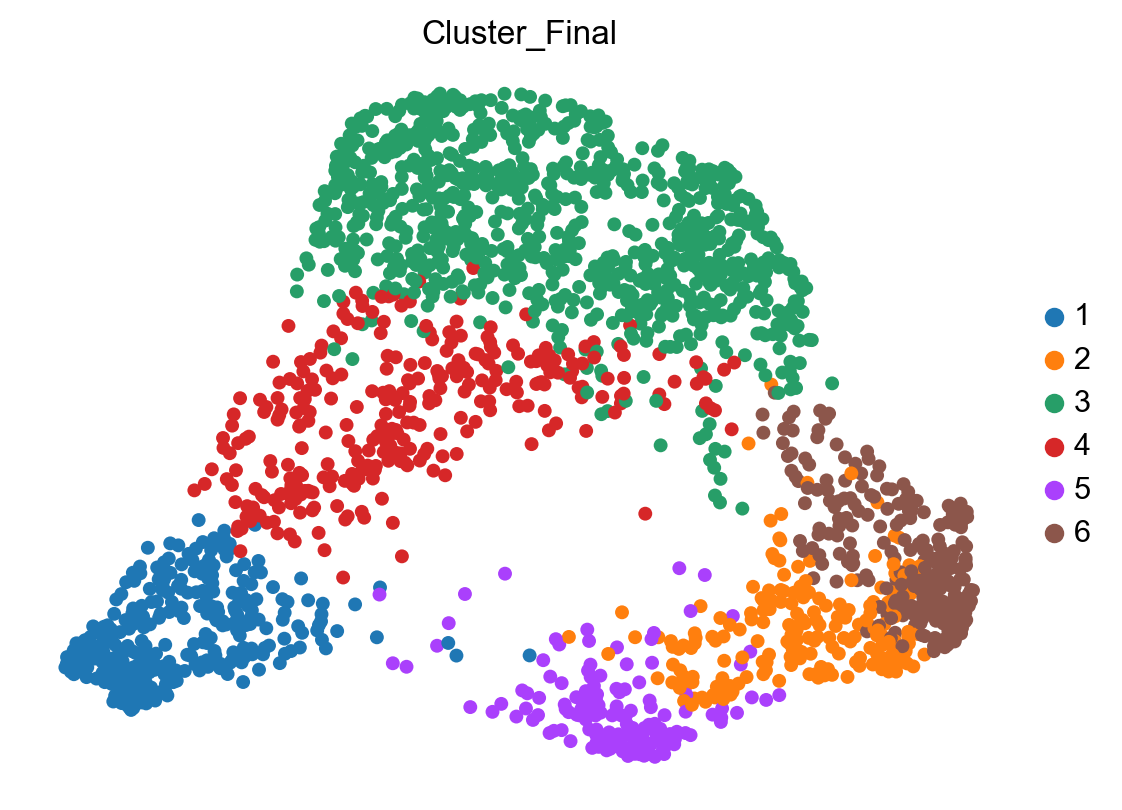

In [2]:
adata_mvi = load_cleaned('New_Analysis/Scenicplus/New_BM4/Teaseq_Multi_VI_BM4_Cleaned.h5ad')
plot_fa_clusters(adata_mvi)


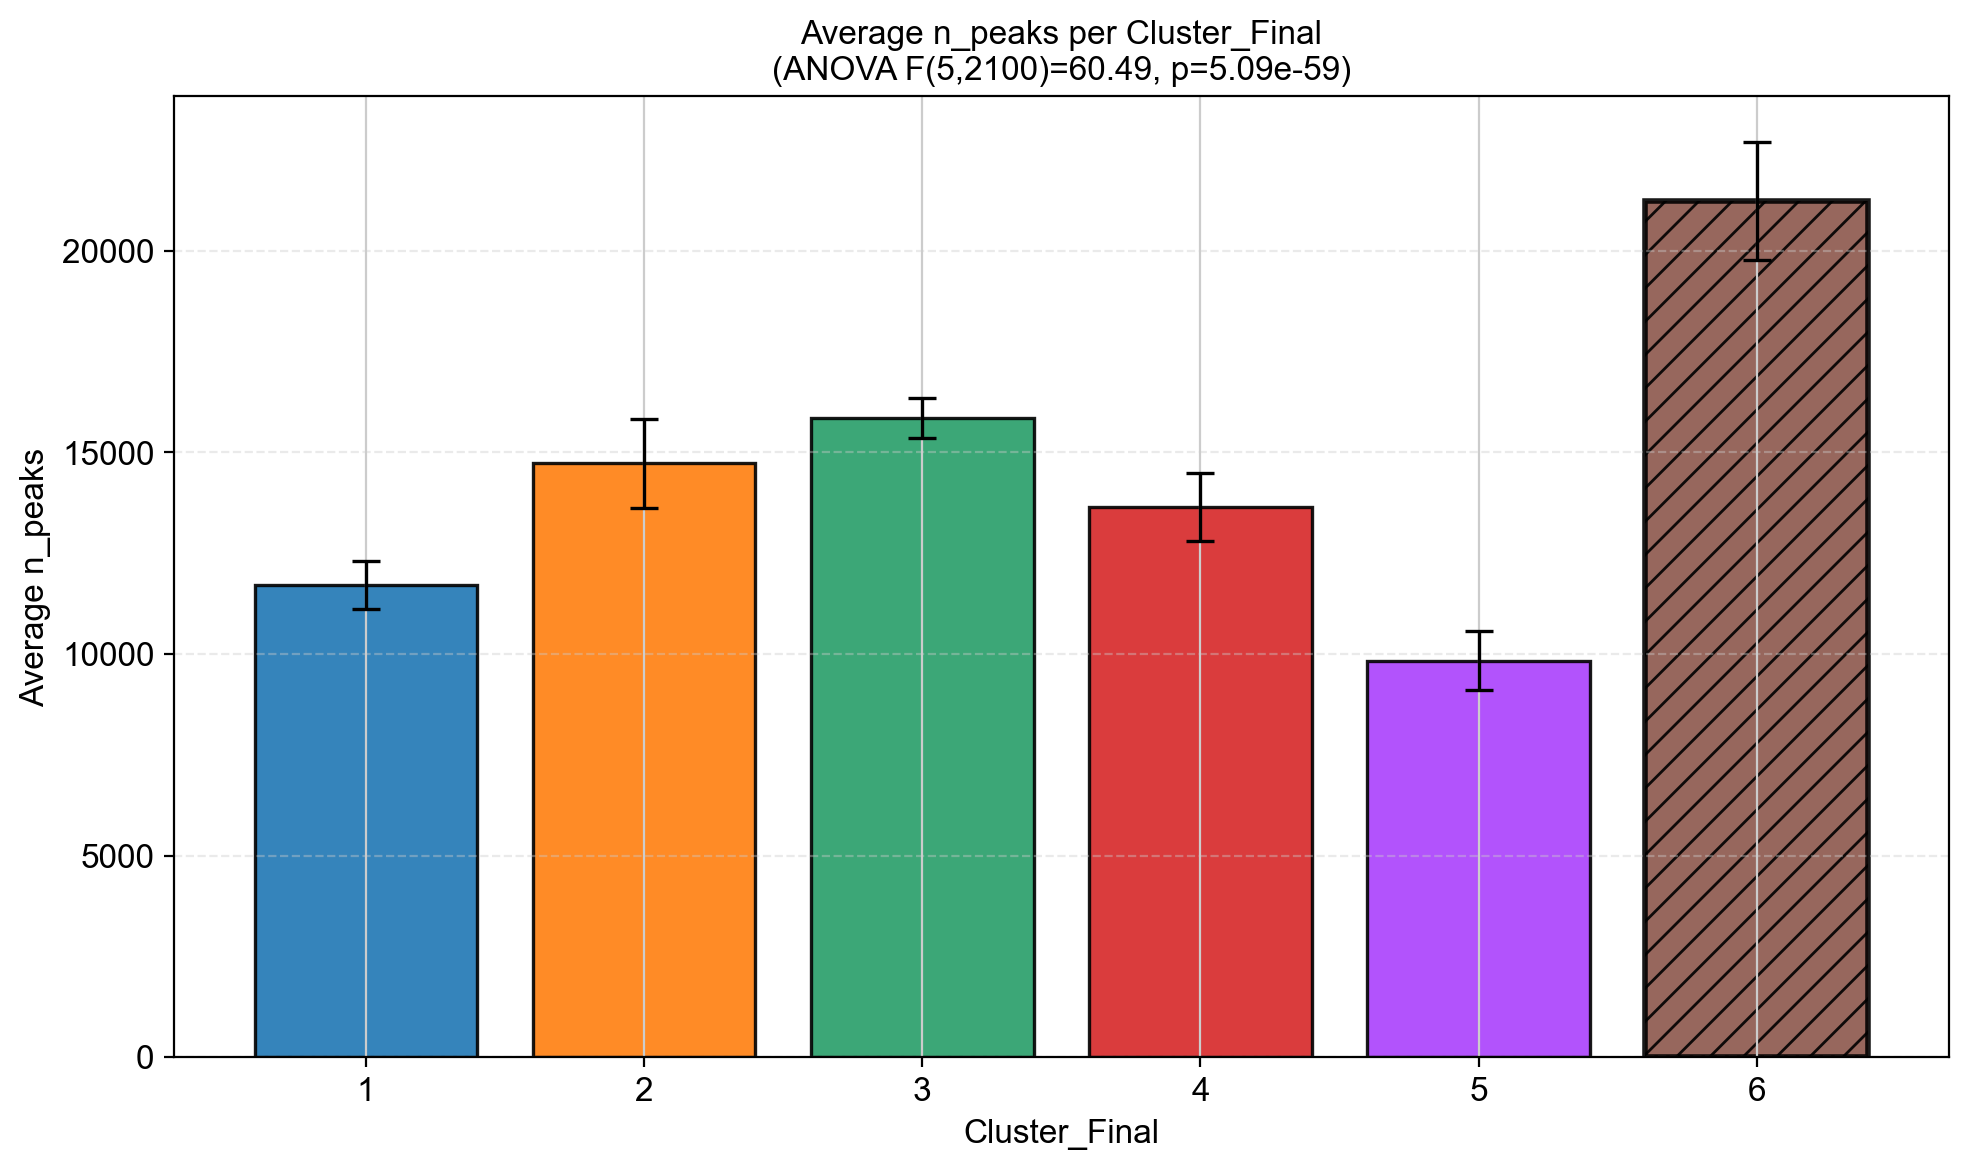


[Summary] n_peaks
            Mean  Count
1  11716.679878    328
2  14733.787129    202
3  15852.633069    883
4  13646.196013    301
5   9838.160000    150
6  21235.128099    242
[ANOVA] F(5,2100)=60.4893 p=5.09e-59


In [3]:
plot_cluster_openness_with_stats(adata_mvi, "n_peaks")


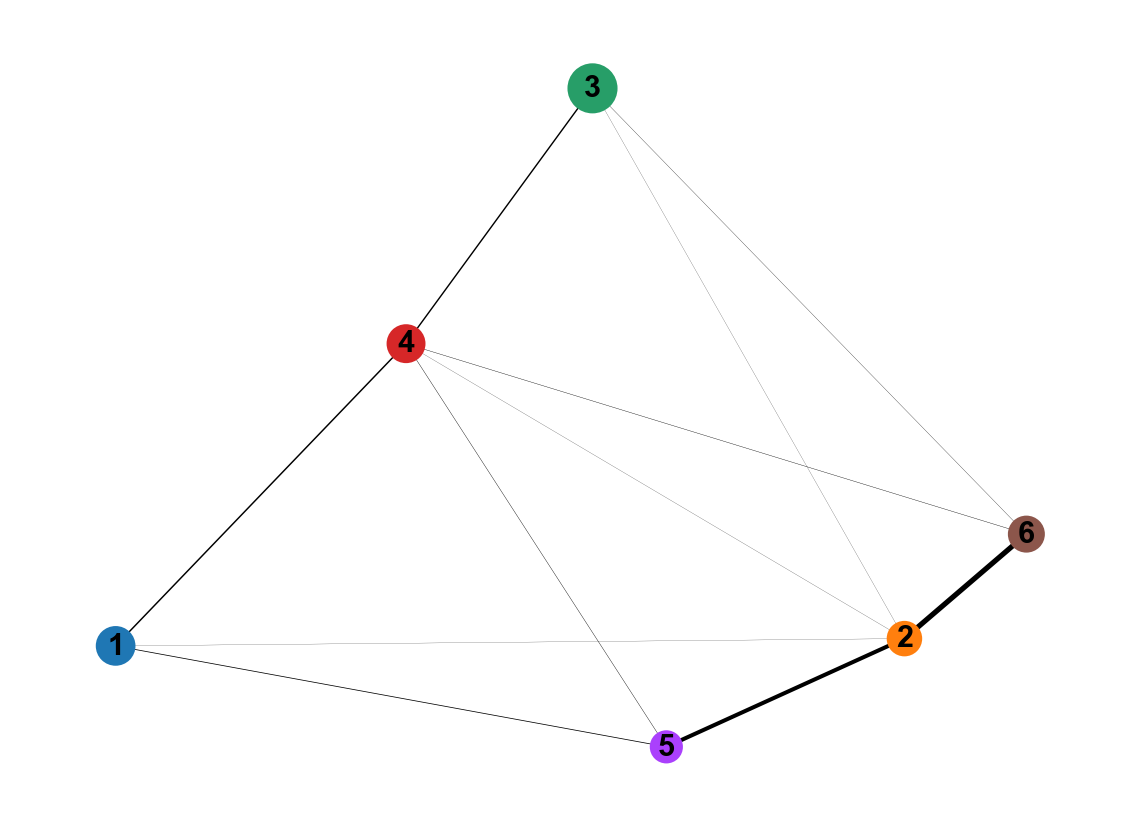

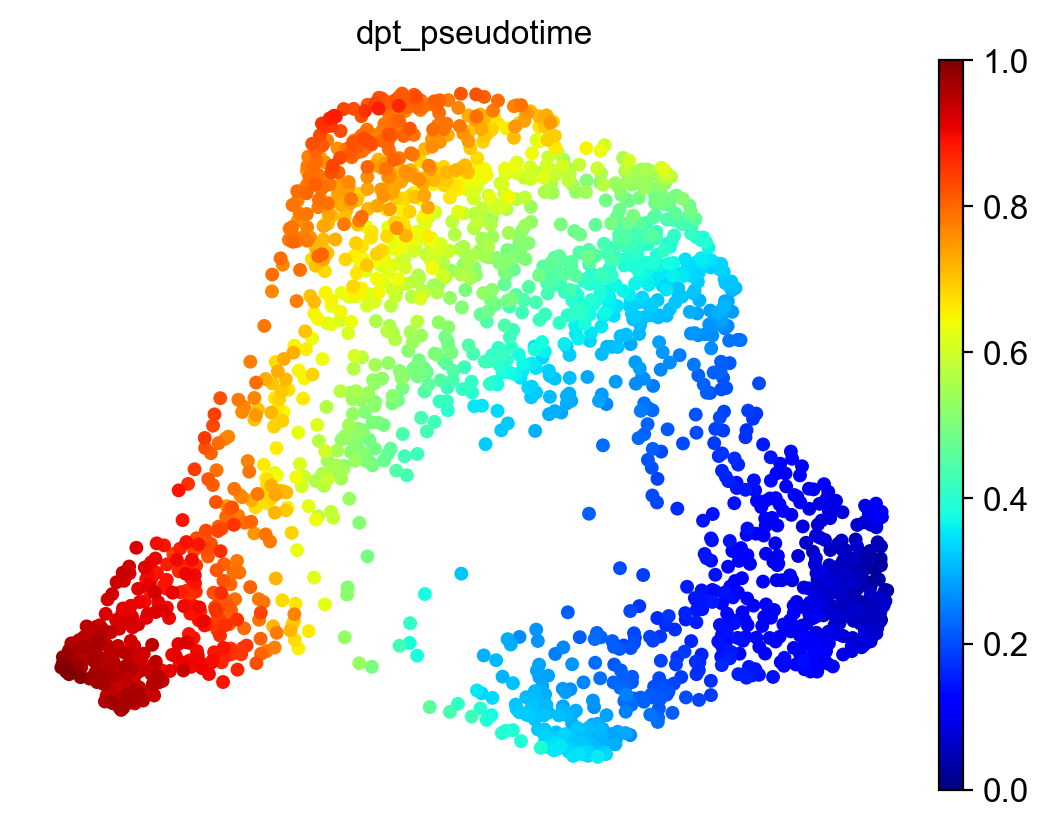

In [4]:
plot_paga_dpt(adata_mvi, root_cell=6, root_index=3)


Patient 3 (BM5 / 19H007)


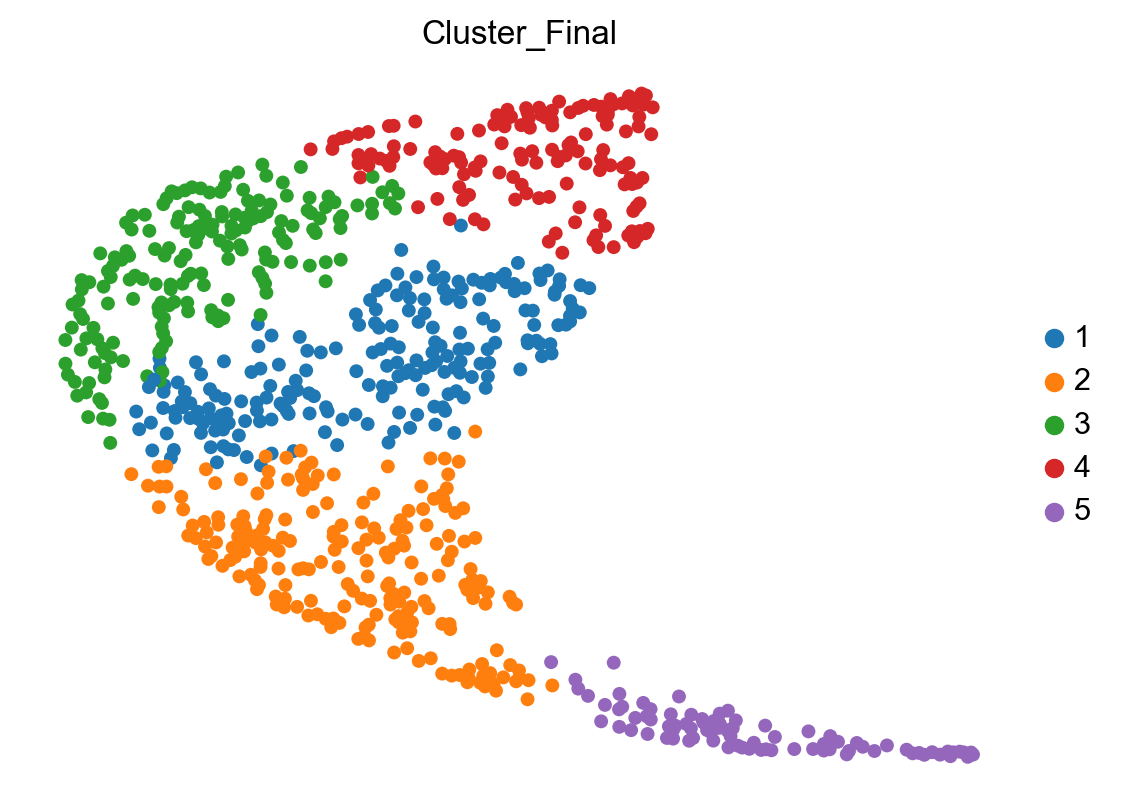

In [5]:
adata_mvi = load_cleaned('New_Analysis/Scenicplus/New_BM5/Teaseq_Multi_VI_BM5_Cleaned.h5ad')
plot_fa_clusters(adata_mvi)


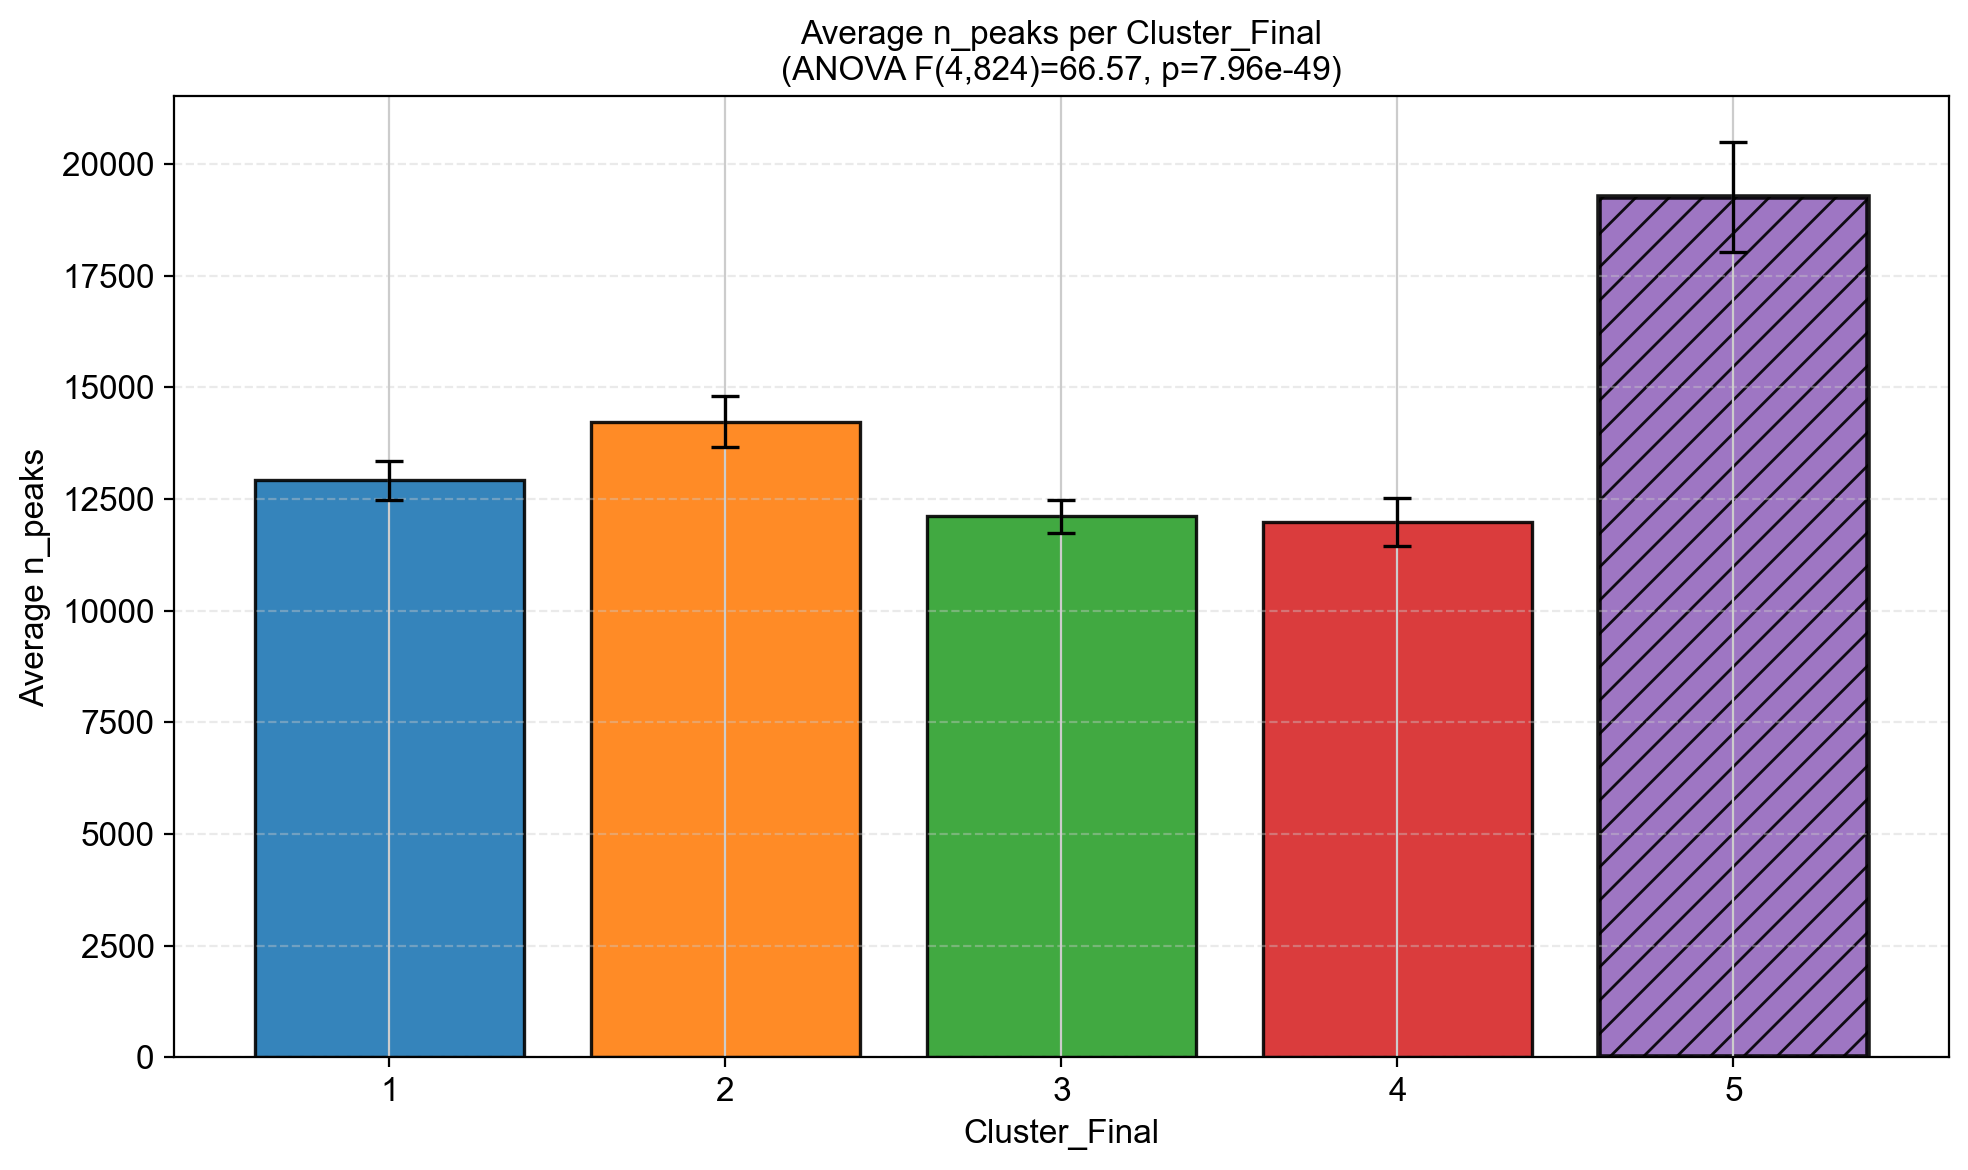


[Summary] n_peaks
            Mean  Count
1  12913.148438    209
2  14224.601562    211
3  12107.876953    179
4  11980.923828    145
5  19257.964844     85
[ANOVA] F(4,824)=66.5736 p=7.96e-49


In [6]:
plot_cluster_openness_with_stats(adata_mvi, "n_peaks")


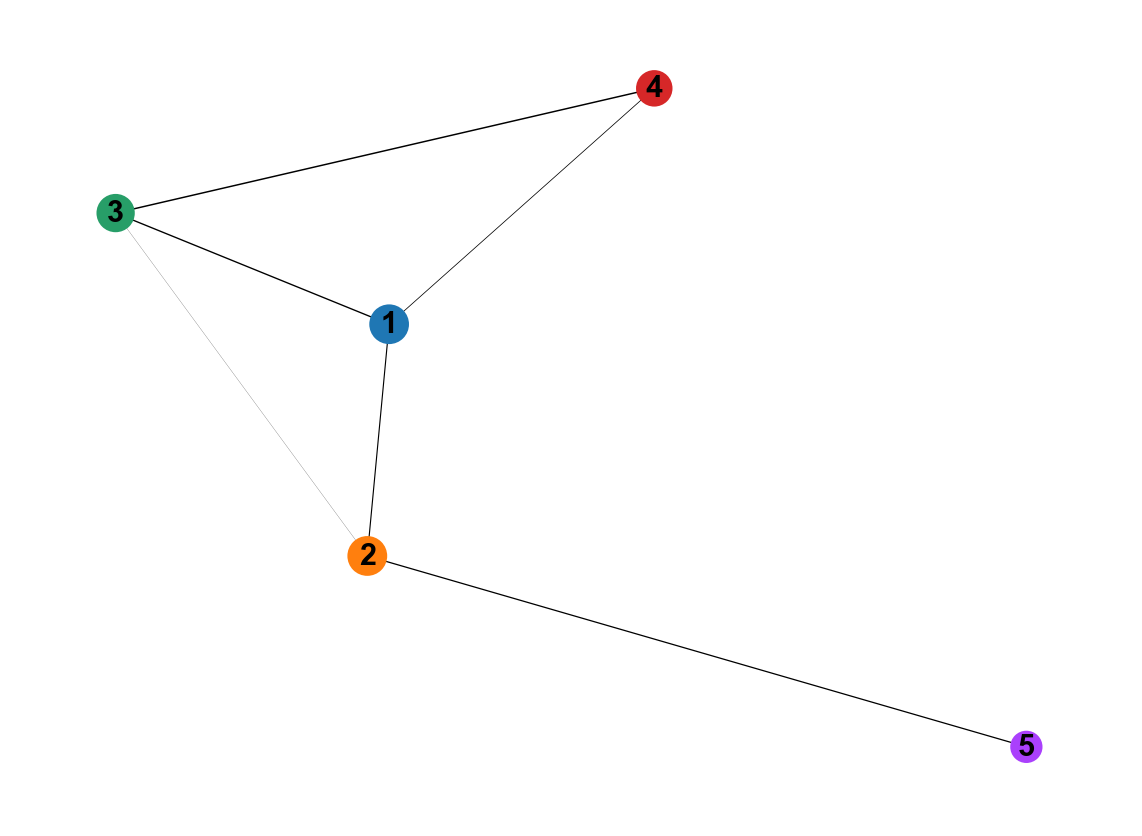

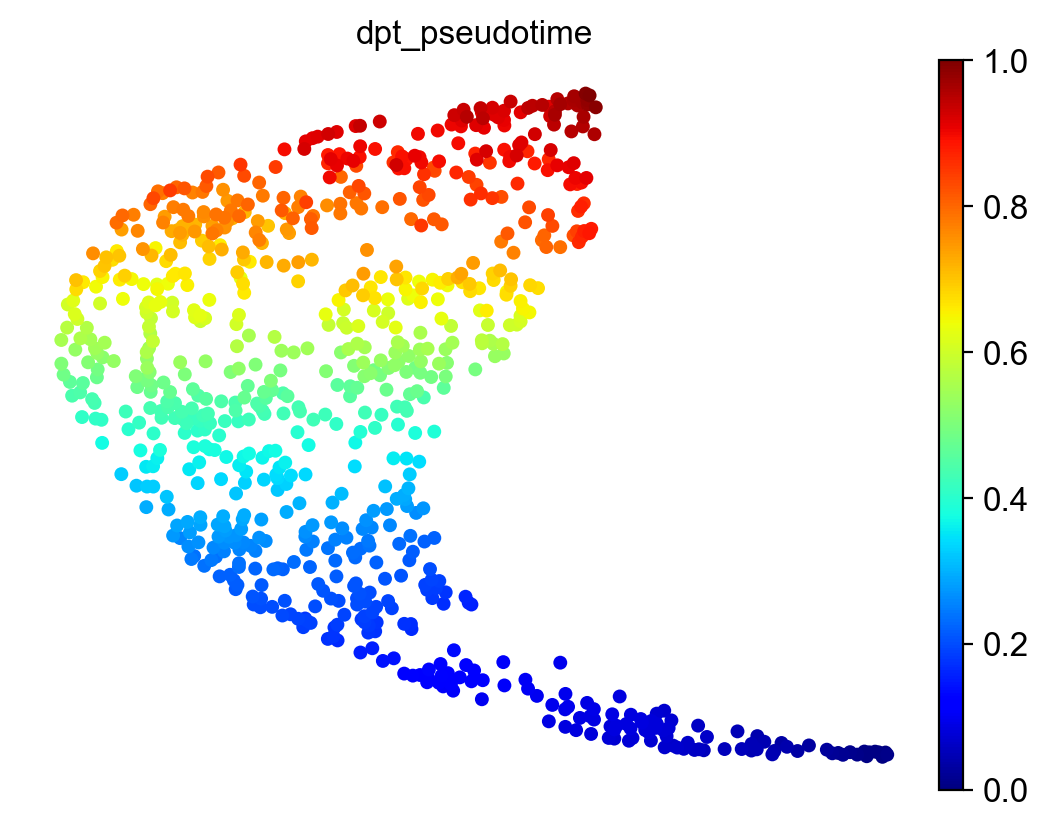

In [7]:
plot_paga_dpt(adata_mvi, root_cell=5, root_index=3)


Patient 4 (BM1 / 05H080)


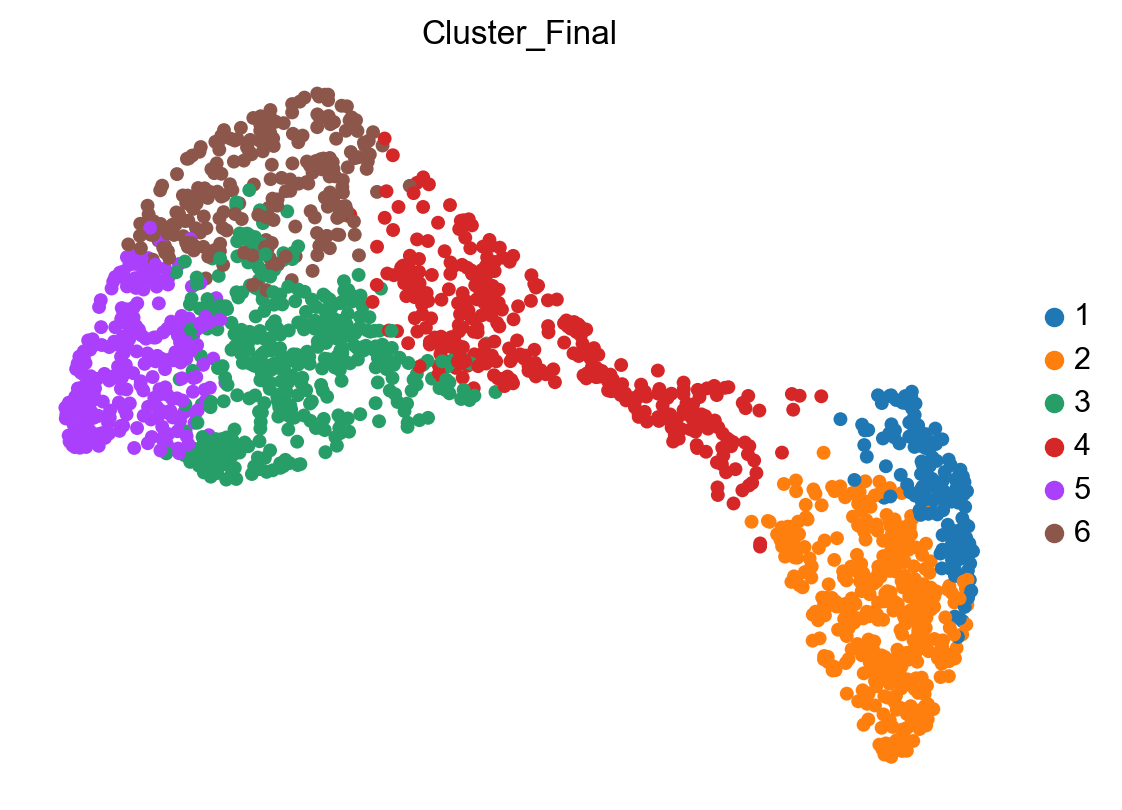

In [8]:
adata_mvi = load_cleaned('New_Analysis/Scenicplus/New_BM1/Teaseq_Multi_VI_BM1_Cleaned.h5ad')
plot_fa_clusters(adata_mvi)


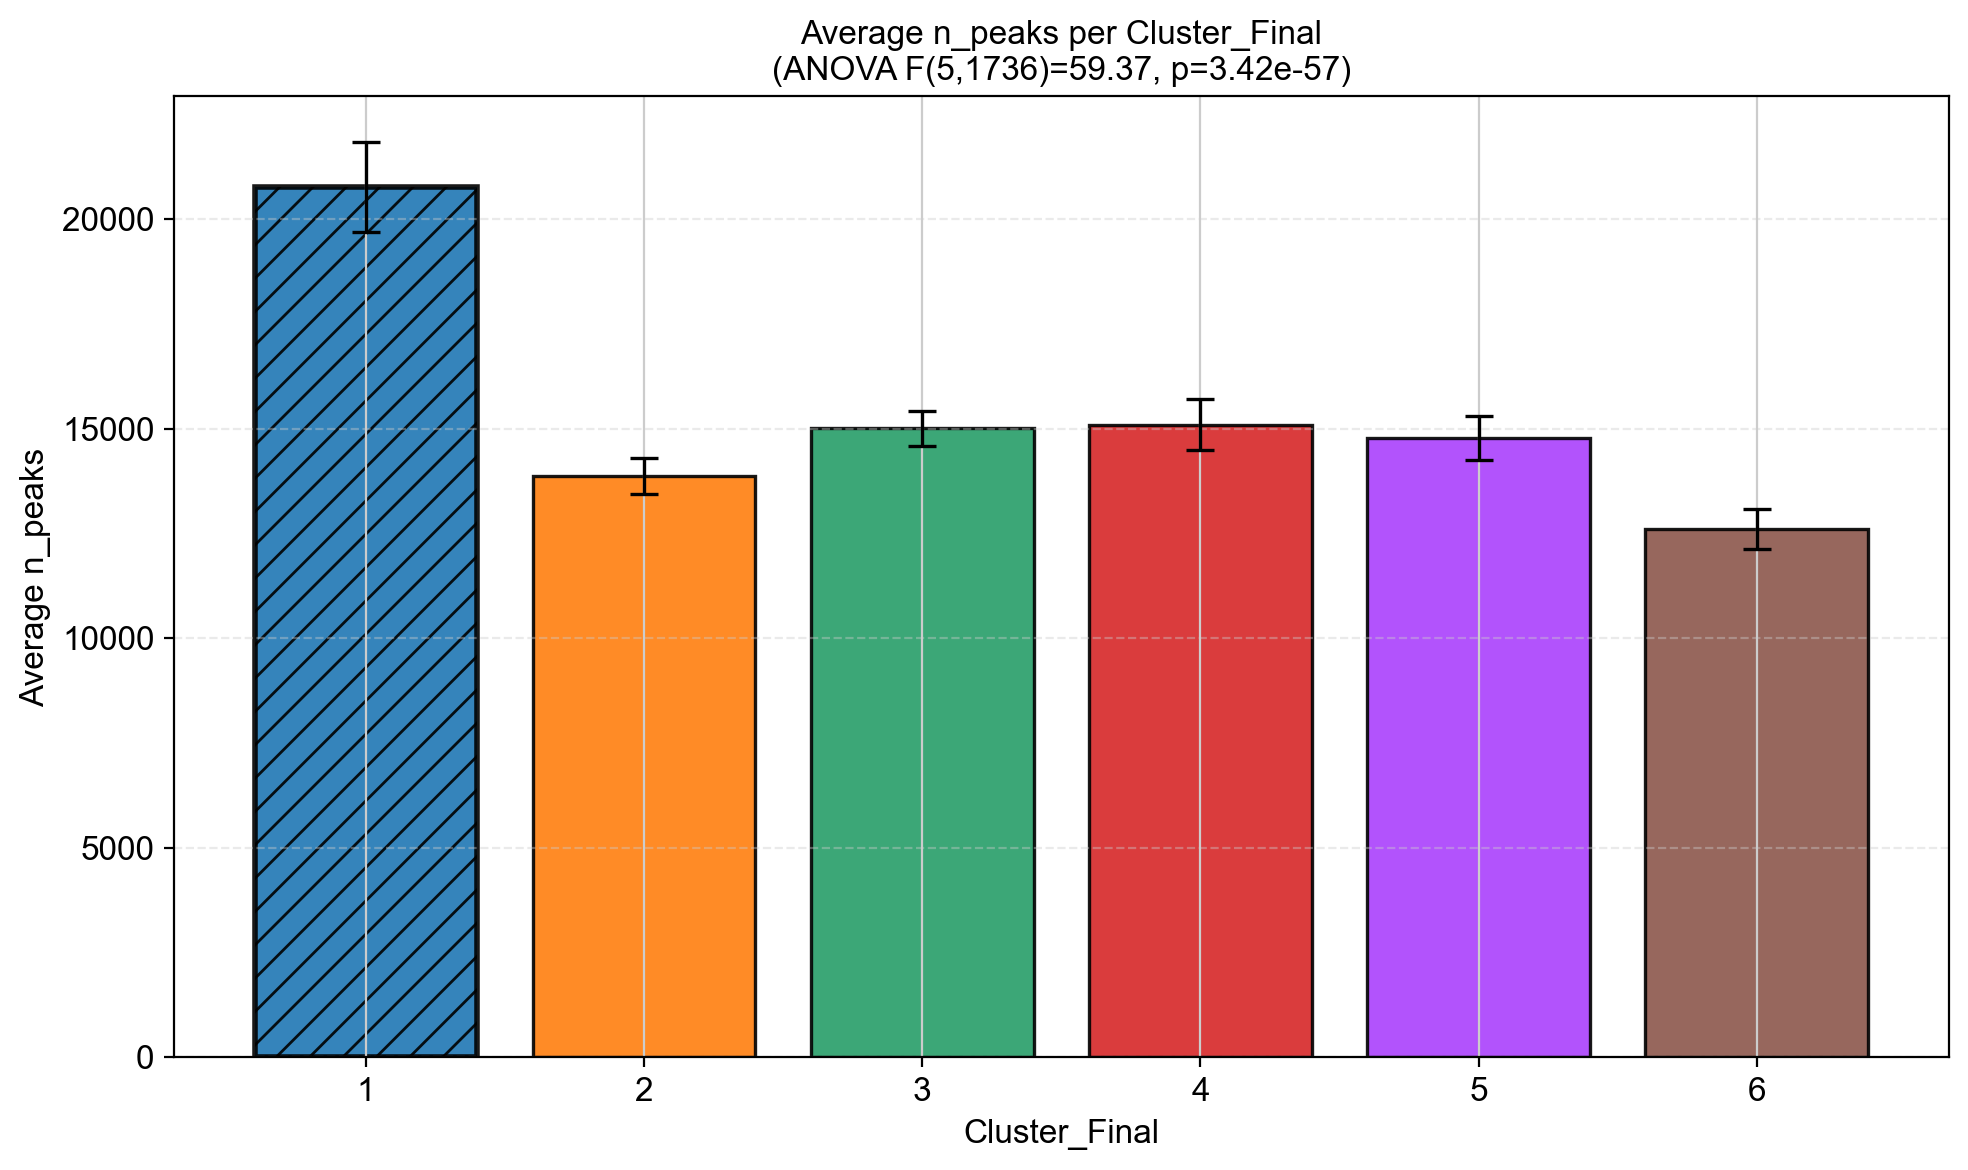


[Summary] n_peaks
            Mean  Count
1  20770.115234    147
2  13867.133789    373
3  15009.051758    386
4  15095.026367    337
5  14783.977539    262
6  12597.636719    237
[ANOVA] F(5,1736)=59.3652 p=3.42e-57


In [9]:
plot_cluster_openness_with_stats(adata_mvi, "n_peaks")


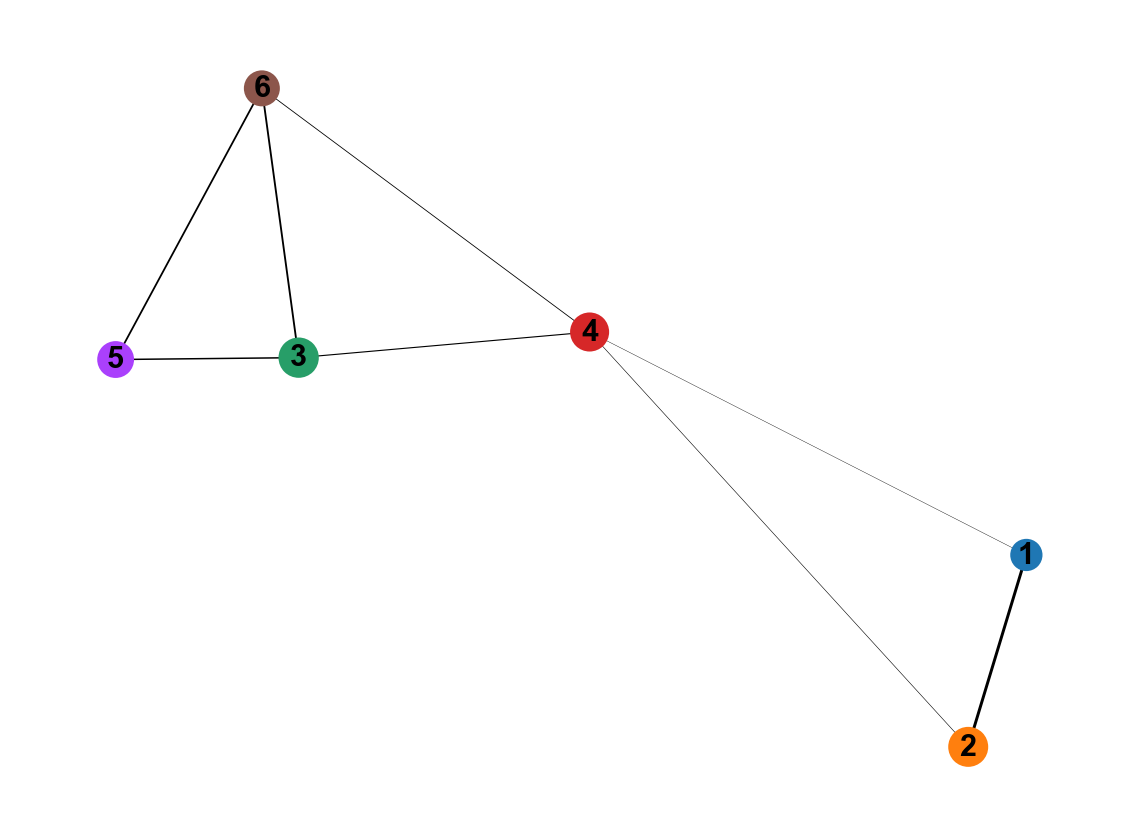

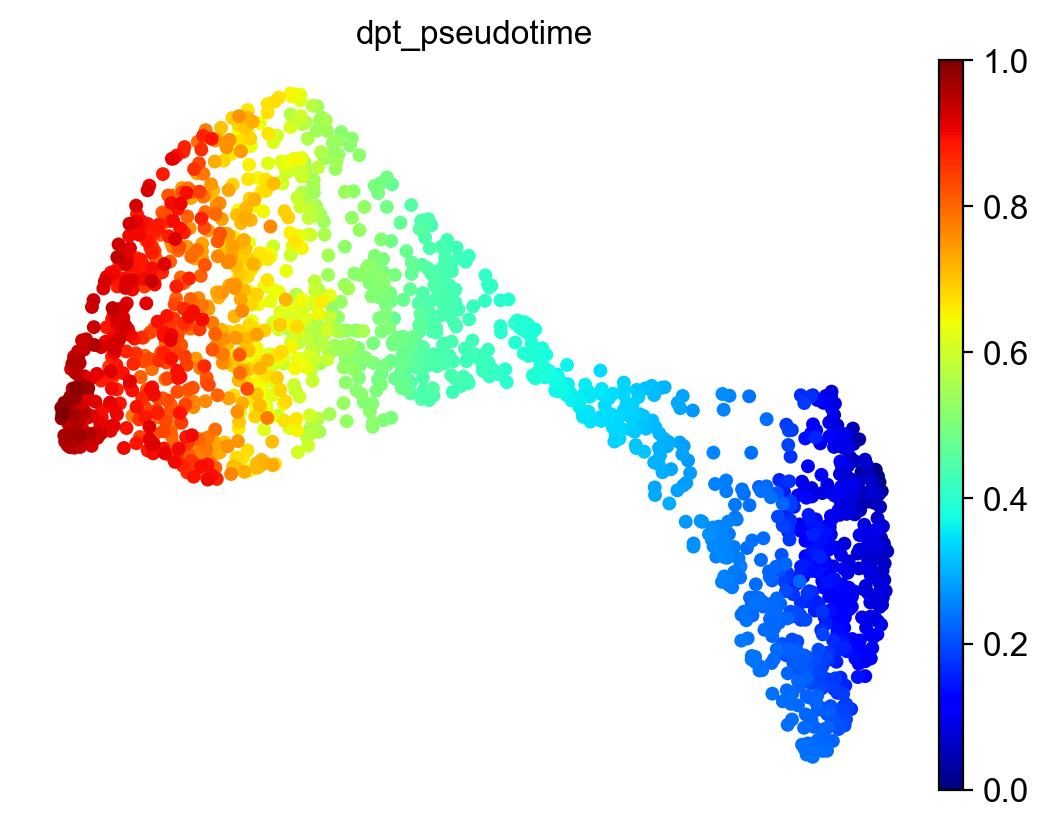

In [10]:
plot_paga_dpt(adata_mvi, root_cell=1, root_index=1)


Patient 5 (BM3 / 21H048)


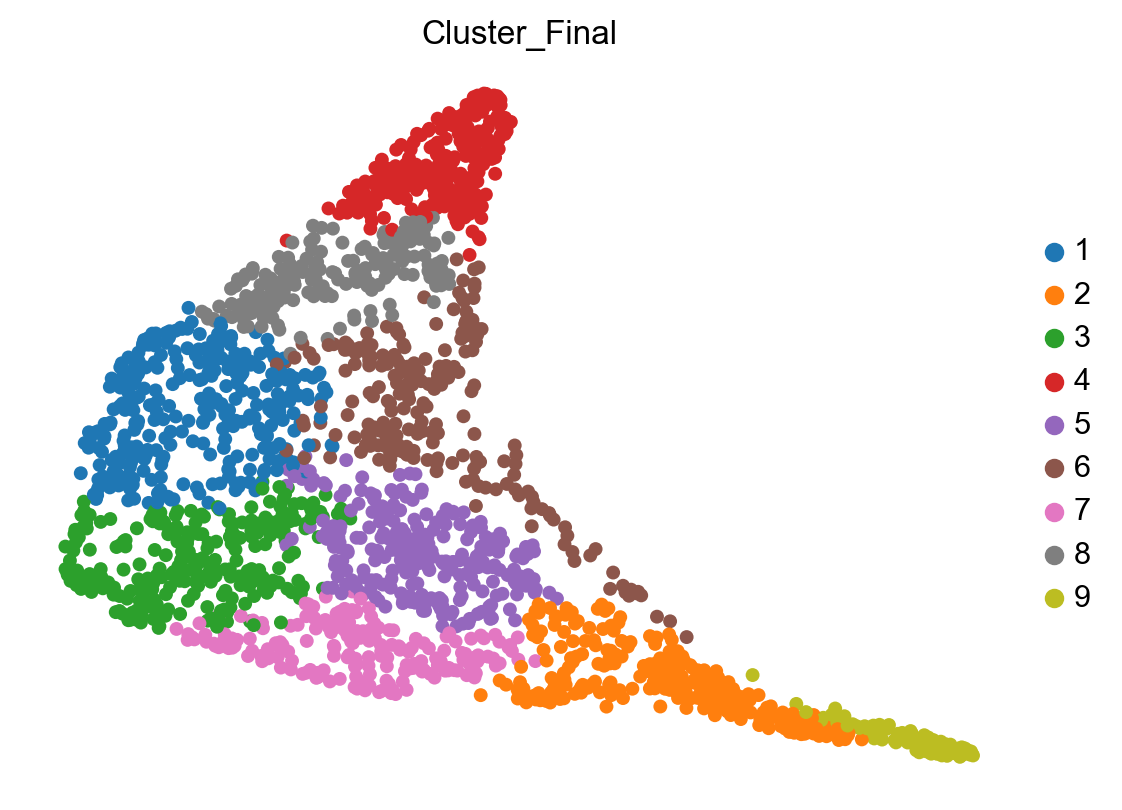

In [11]:
adata_mvi = load_cleaned('New_Analysis/Scenicplus/New_BM3/Teaseq_Multi_VI_BM3_Cleaned.h5ad')
plot_fa_clusters(adata_mvi)


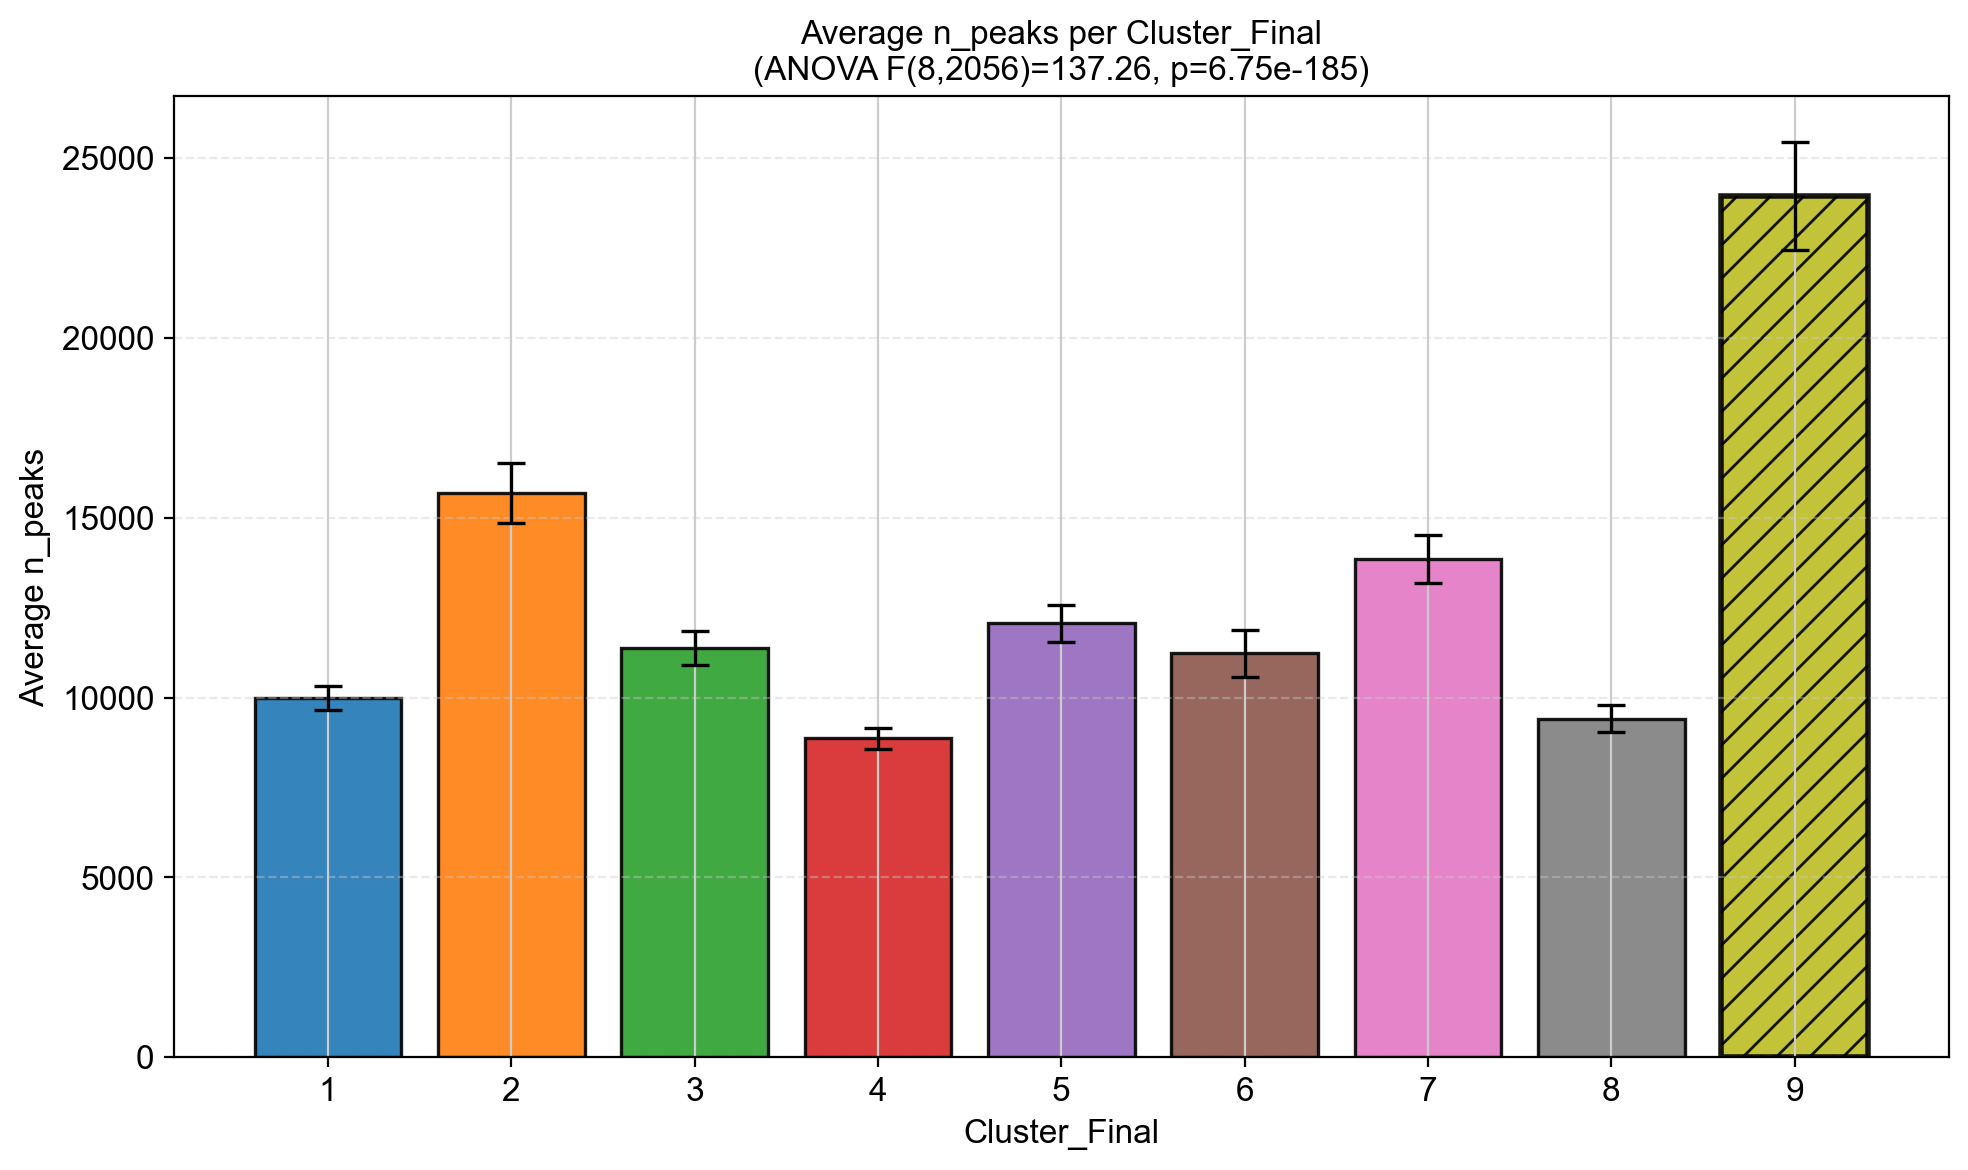


[Summary] n_peaks
            Mean  Count
1   9996.994141    318
2  15677.479492    271
3  11385.526367    266
4   8871.851562    263
5  12067.570312    249
6  11232.144531    222
7  13852.357422    193
8   9418.564453    193
9  23940.210938     90
[ANOVA] F(8,2056)=137.2645 p=6.75e-185


In [12]:
plot_cluster_openness_with_stats(adata_mvi, "n_peaks")


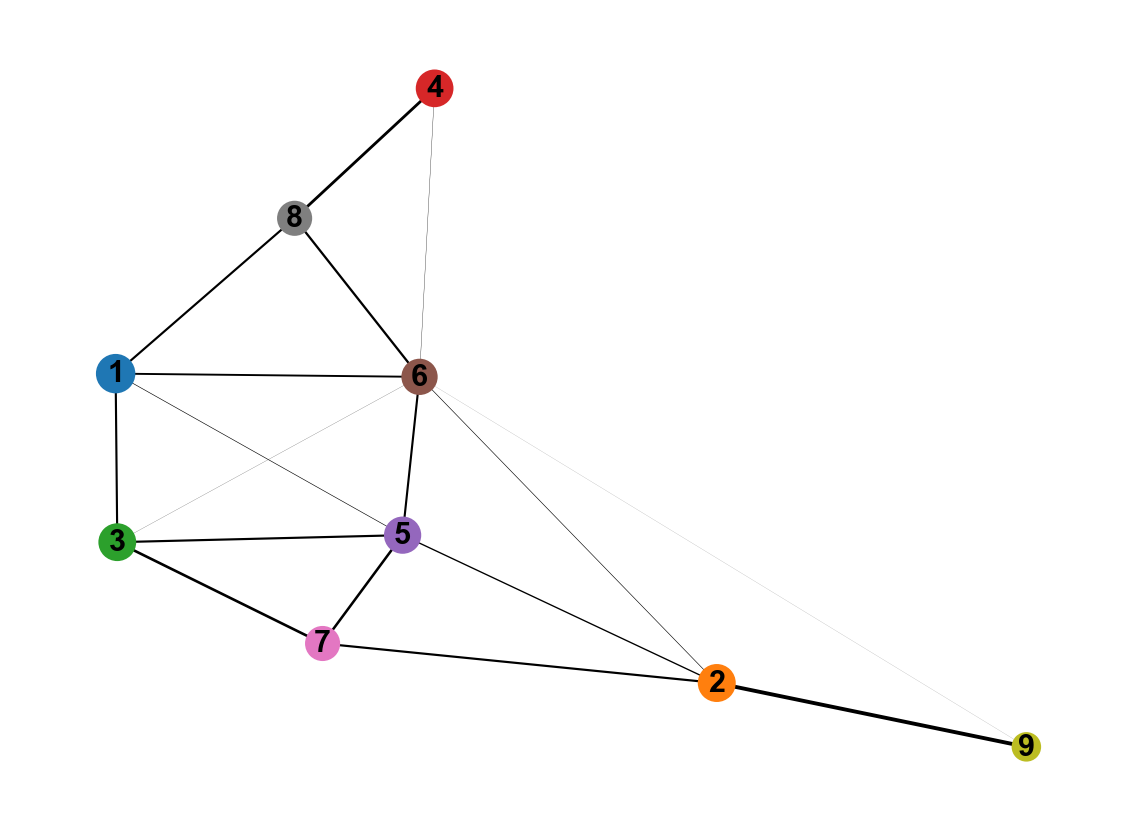

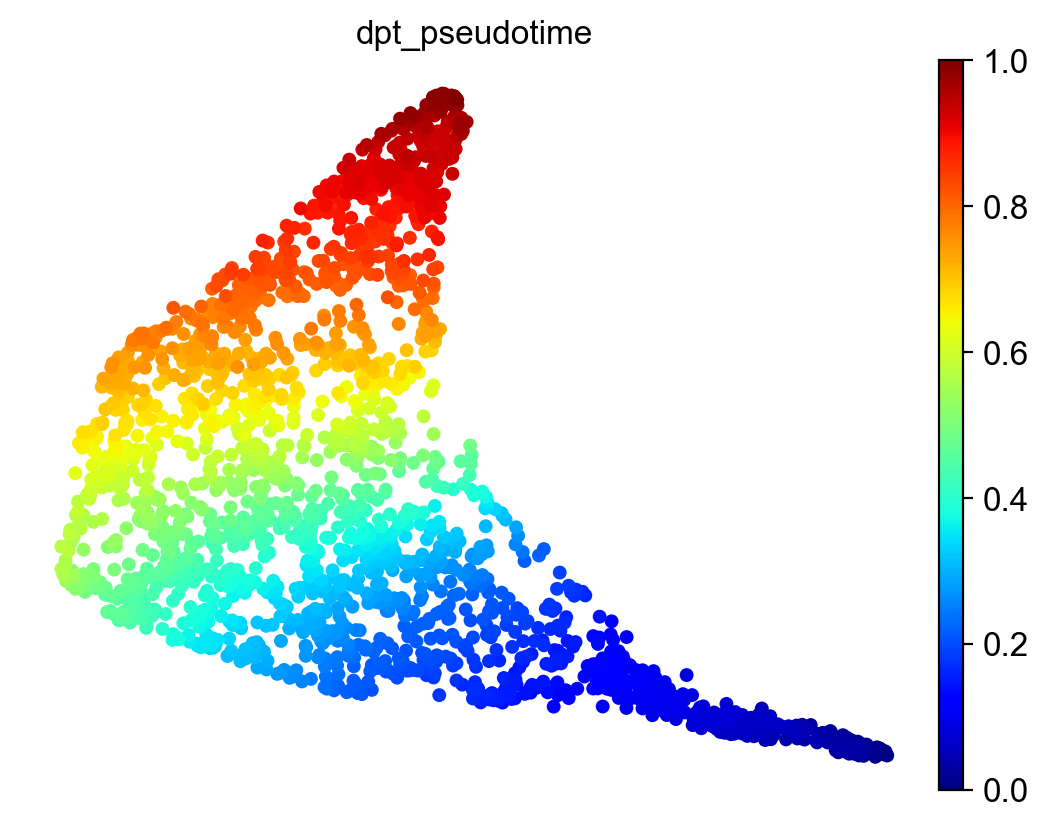

In [13]:
plot_paga_dpt(adata_mvi, root_cell=9, root_index=3)
